# 工业故障诊断 AI Agent

基于 LangGraph 构建的工业故障诊断 Agent，具有以下特性：
- **RAG 双擎检索**：Milvus 内部 SOP + Tavily 外部搜索
- **知识过滤融合**：LLM 自动清洗外部噪音
- **Mermaid 流程图生成**：输出可执行的故障排查流程图
- **自主审计 + 逐问人机协同**：审计发现问题时逐个问题中断收集专家反馈
- **并发与循环**：Fan-out/Fan-in 并发检索 + 逐问循环 + 修订循环
- **4种 MessageState**：SystemMessage、HumanMessage、AIMessage、ToolMessage
- **Langfuse 可观测性**：全链路追踪

In [ ]:
# 安装依赖（如已安装可跳过）
# !pip install langgraph langchain langchain-openai langchain-community tavily-python pymilvus langfuse langgraph-checkpoint nbformat

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

print('环境变量加载完成:')
ark_key = os.environ.get('ARK_API_KEY', '')
print(f'  ARK_API_KEY: ***{ark_key[-6:]}' if ark_key else '  ARK_API_KEY: NOT SET')
print(f'  ARK_BASE_URL: {os.environ.get("ARK_BASE_URL", "NOT SET")}')
print(f'  MILVUS_HOST: {os.environ.get("MILVUS_HOST", "NOT SET")}')

tavily_key = os.environ.get('trivily_key', '')
print(f'  TAVILY_API_KEY: ***{tavily_key[-6:]}' if tavily_key else '  TAVILY_API_KEY: NOT SET')
print(f'  LANGFUSE_ENABLED: {os.environ.get("LANGFUSE_ENABLED", "false")}')

环境变量加载完成:
  ARK_API_KEY: ***hhlzia
  ARK_BASE_URL: https://api.siliconflow.cn/v1
  MILVUS_HOST: 150.158.123.242
  TAVILY_API_KEY: ***LOMHcf
  LANGFUSE_ENABLED: true


## 1. 初始化 Milvus 知识库

将10条工业故障诊断SOP灌入Milvus向量数据库。

In [3]:
from sop_documents import SOP_DOCUMENTS
print(f'共 {len(SOP_DOCUMENTS)} 条SOP文档:')
for doc in SOP_DOCUMENTS:
    print(f'  [{doc["category"]}] {doc["title"]}')

共 26 条SOP文档:
  [通讯故障] PLC通讯故障诊断知识
  [电机故障] 电机过热故障诊断知识
  [传感器故障] 传感器信号异常诊断知识
  [液压故障] 液压系统压力不足诊断知识
  [变频器故障] 变频器报警故障诊断知识
  [压缩机故障] 压缩机异常停机诊断知识
  [输送设备故障] 传送带跑偏故障诊断知识
  [电气故障] 电气柜温度告警诊断知识
  [通讯故障] DCS系统通讯中断诊断知识
  [气动故障] 气动执行机构故障诊断知识
  [旋转设备故障] 锅炉给水泵振动异常诊断知识
  [电气故障] UPS不间断电源故障诊断知识
  [电机故障] 步进电机丢步诊断知识
  [锅炉故障] 工业锅炉水位异常诊断知识
  [电机故障] 伺服电机报警诊断知识
  [真空设备故障] 真空泵抽速不足诊断知识
  [制冷设备故障] 工业制冷机组高压报警诊断知识
  [通讯故障] PLC模拟量信号漂移诊断知识
  [通讯故障] 工业网络交换机故障诊断知识
  [PLC通讯故障] PROFIBUS-DP通讯故障诊断知识
  [PLC通讯故障] PLC以太网通讯故障诊断知识
  [PLC通讯故障] PLC通讯模块硬件故障诊断知识
  [PLC通讯故障] PLC通讯参数配置错误诊断知识
  [PLC通讯故障] PLC通讯电磁干扰诊断知识
  [PLC通讯故障] PLC冗余系统通讯故障诊断知识
  [PLC通讯故障] PLC与上位机SCADA通讯故障诊断知识


In [4]:
# 初始化Milvus知识库（首次运行需要，后续可跳过）
from init_knowledge_base import connect_milvus, create_collection, insert_documents, verify_search

connect_milvus()
collection = create_collection()
insert_documents(collection)
verify_search(collection)
print('知识库初始化完成！')

d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:42: PyMilvusDeprecationWarning: `connections.connect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  connections.connect(**connect_kwargs)
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:59: PyMilvusDeprecationWarning: `utility.has_collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  if utility.has_collection(COLLECTION_NAME, using="fault_conn"):
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:60: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection = Collection(name=COLLECTION_NAME, using="fault_conn")
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:62: PyMilvusDeprecationWarning: `Collection.drop` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.


[Milvus] connected to 150.158.123.242:19530
[Milvus] collection 'industrial_fault_knowledge' already exists, dropping and recreating...


d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:72: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection = Collection(name=COLLECTION_NAME, schema=schema, using="fault_conn")
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:75: PyMilvusDeprecationWarning: `Collection.create_index` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.create_index(field_name="vector", index_params=index_params)
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:76: PyMilvusDeprecationWarning: `Collection.create_index` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.create_index(field_name="category", index_params={"index_type": "Trie"})


[Milvus] collection 'industrial_fault_knowledge' created with dim=2560
[Embedding] starting embedding for 26 documents...
  [1/26] embedded: PLC通讯故障诊断知识
  [2/26] embedded: 电机过热故障诊断知识
  [3/26] embedded: 传感器信号异常诊断知识
  [4/26] embedded: 液压系统压力不足诊断知识
  [5/26] embedded: 变频器报警故障诊断知识
  [6/26] embedded: 压缩机异常停机诊断知识
  [7/26] embedded: 传送带跑偏故障诊断知识
  [8/26] embedded: 电气柜温度告警诊断知识
  [9/26] embedded: DCS系统通讯中断诊断知识
  [10/26] embedded: 气动执行机构故障诊断知识
  [11/26] embedded: 锅炉给水泵振动异常诊断知识
  [12/26] embedded: UPS不间断电源故障诊断知识
  [13/26] embedded: 步进电机丢步诊断知识
  [14/26] embedded: 工业锅炉水位异常诊断知识
  [15/26] embedded: 伺服电机报警诊断知识
  [16/26] embedded: 真空泵抽速不足诊断知识
  [17/26] embedded: 工业制冷机组高压报警诊断知识
  [18/26] embedded: PLC模拟量信号漂移诊断知识
  [19/26] embedded: 工业网络交换机故障诊断知识
  [20/26] embedded: PROFIBUS-DP通讯故障诊断知识
  [21/26] embedded: PLC以太网通讯故障诊断知识
  [22/26] embedded: PLC通讯模块硬件故障诊断知识
  [23/26] embedded: PLC通讯参数配置错误诊断知识
  [24/26] embedded: PLC通讯电磁干扰诊断知识
  [25/26] embedded: PLC冗余系统通讯故障诊断知识
  [26/26] embedded: PLC与上位机SCADA通讯故障诊断知识


d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:98: PyMilvusDeprecationWarning: `Collection.insert` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.insert(data)
d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:99: PyMilvusDeprecationWarning: `Collection.flush` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.flush()


[Milvus] inserted 26 documents into 'industrial_fault_knowledge'


d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:104: PyMilvusDeprecationWarning: `Collection.load` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.load()



[Verify] search query: 'PLC通讯故障诊断步骤'
  score=0.6144 | title=PLC通讯故障诊断知识 | category=通讯故障
  score=0.5664 | title=PLC通讯参数配置错误诊断知识 | category=PLC通讯故障
  score=0.5547 | title=PLC以太网通讯故障诊断知识 | category=PLC通讯故障
[Verify] search verification passed!

知识库初始化完成！


d:\git_repo_file\LangGraph_Agent_Work\init_knowledge_base.py:108: PyMilvusDeprecationWarning: `Collection.search` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  results = collection.search(


## 2. 构建 LangGraph Agent

导入核心模块并构建图。

In [5]:
from fault_agent import (
    build_app, run_fault_agent,
    AgentState, tools_list,
    dispatch_node, retrieve_internal_node, search_agent_node,
    filter_knowledge_node, generate_diagram_node,
    audit_diagram_node, evaluate_questions_node,
    ask_expert_per_question_node, refine_diagram_node,
    tavily_search, llm
)
from langgraph.types import Command

app = build_app()
print('Agent 构建完成！')
print(f'图节点: {list(app.get_graph().nodes.keys())}')
print(f'图边数: {len(list(app.get_graph().edges))}')

Agent 构建完成！
图节点: ['__start__', 'dispatch', 'retrieve_internal', 'search_agent', 'tools_node', 'filter', 'generate', 'audit', 'evaluate_questions', 'ask_expert', 'refine', '__end__']
图边数: 14


## 3. 可视化 Agent 图结构

展示 LangGraph 的节点和边结构。

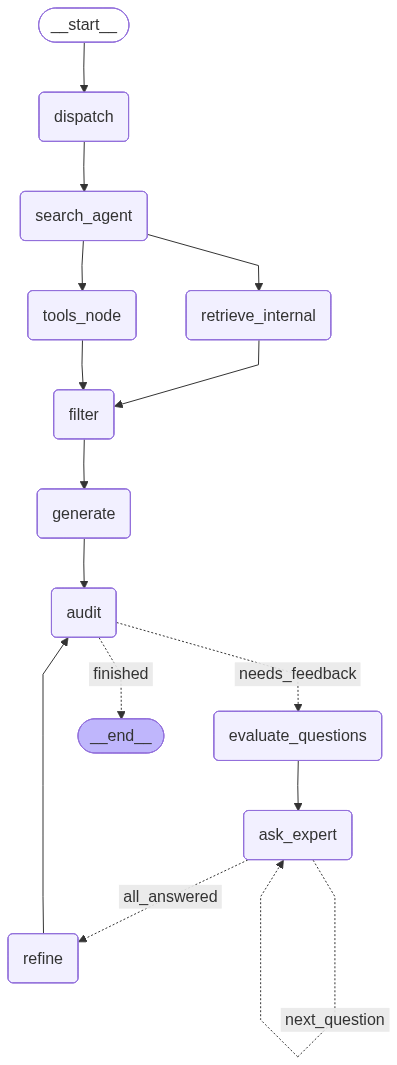


=== 图结构详情 ===
节点: ['__start__', 'dispatch', 'retrieve_internal', 'search_agent', 'tools_node', 'filter', 'generate', 'audit', 'evaluate_questions', 'ask_expert', 'refine', '__end__']

边:
  __start__ -> dispatch
  ask_expert -> ask_expert [next_question] (条件)
  ask_expert -> refine [all_answered] (条件)
  audit -> __end__ [finished] (条件)
  audit -> evaluate_questions [needs_feedback] (条件)
  dispatch -> search_agent
  evaluate_questions -> ask_expert
  filter -> generate
  generate -> audit
  refine -> audit
  retrieve_internal -> filter
  search_agent -> retrieve_internal
  search_agent -> tools_node
  tools_node -> filter


In [6]:
from IPython.display import Image, display

try:
    img = app.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f'无法渲染图片: {e}')

print('\n=== 图结构详情 ===')
print('节点:', list(app.get_graph().nodes.keys()))
print('\n边:')
for edge in app.get_graph().edges:
    cond = ' (条件)' if edge.conditional else ''
    data = f' [{edge.data}]' if edge.data else ''
    print(f'  {edge.source} -> {edge.target}{data}{cond}')

## 4. 测试用例1：自动模式（审计通过，无需人机循环）

故障描述：西门子 S7-1200 PLC 通讯故障

预期：Milvus 检索到 PLC 相关 SOP，生成完整流程图，审计通过。

In [7]:
result1 = run_fault_agent('西门子 S7-1200 PLC 通讯故障', auto_mode=True)

print('\n' + '='*60)
print('测试用例1 - 消息类型验证:')
msg_types = {}
for m in result1.get('messages', []):
    t = type(m).__name__
    msg_types[t] = msg_types.get(t, 0) + 1
print(f'  {msg_types}')
print(f'  内部知识: {"有" if result1.get("internal_knowledge") else "无"}')
print(f'  过滤上下文: {"有" if result1.get("filtered_context") else "无"}')

[Langfuse] 可观测性已启用，trace 将上报至 Langfuse 平台

工业故障诊断 Agent 启动
故障描述: 西门子 S7-1200 PLC 通讯故障
模式: 自动



d:\git_repo_file\LangGraph_Agent_Work\fault_agent.py:91: PyMilvusDeprecationWarning: `connections.connect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  connections.connect(**connect_kwargs)
d:\git_repo_file\LangGraph_Agent_Work\fault_agent.py:107: PyMilvusDeprecationWarning: `utility.has_collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  if not utility.has_collection(COLLECTION_NAME, using=FAULT_CONN_ALIAS):
d:\git_repo_file\LangGraph_Agent_Work\fault_agent.py:109: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection = Collection(name=COLLECTION_NAME, using=FAULT_CONN_ALIAS)
d:\git_repo_file\LangGraph_Agent_Work\fault_agent.py:110: PyMilvusDeprecationWarning: `Collection.load` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  collection.load

[知识融合] 内部知识: 2028字符, 外部知识: 557字符

[审计发现] 存在 3 个需要专家确认的问题：
  1. Ping测试判断节点M中，当Ping不通但以太网Link/Act灯亮时，应增加分支指向IP配置或协议检查，当前流程是否遗漏？
  2. ERR灯红灯闪烁后等待30秒，若仍持续闪烁（非常亮也非熄灭），应如何处理？是否需要增加分支指向配置错误检查？
  3. 以太网Link/Act灯不亮但物理连接和交换机端口均正常时，是否应直接进入硬件故障诊断（如交叉验证）而非通过Ping测试绕回？

--- 审计问题 [1/3] ---
问题: Ping测试判断节点M中，当Ping不通但以太网Link/Act灯亮时，应增加分支指向IP配置或协议检查，当前流程是否遗漏？
当前流程图:
```mermaid
flowchart TD
    A([故障报告：西门子 S7-1200 PLC 通讯故障]) --> B{观察通讯模块指示灯}
    B -- ERR灯红灯常亮 --> C[判断：硬件故障或固件损坏]
    B -- ERR灯红灯闪烁 --> D[等待30秒，观察是否变为常亮或熄灭]
    B -- 以太网Link/Act灯不亮 --> E[检查物理连接：网线、水晶头、交换机端口]
    B -- 以太网Link/Act灯正常闪烁 --> F{进行Ping测试}

    D --> G{30秒后ERR灯状态？}
    G -- 变为常亮 --> C
    G -- 熄灭或正常 --> F

    E --> H{物理连接是否正常？}
    H -- 否 --> I[更换或重新制作网线/连接器，确保屏蔽接地]
    H -- 是 --> J[检查交换机端口、VLAN配置、MAC地址表]
    J --> K{交换机端口正常？}
    K -- 否 --> L[更换交换机端口或重启交换机]
    K -- 是 --> F

    F --> M{Ping结果？}
    M -- Ping不通且链路灯灭 --> N[物理层故障：检查线缆、电源、终端电阻]
    M -- Ping通但S7通讯不通 --> O[协议或连接资源问题]
    M -- Ping延迟>10ms或丢包 --> P[网络拥堵或EMI干扰]

    N -->

## 5. 测试用例2：变频器过流故障（触发 Tavily 外部搜索 → ToolMessage）

故障描述：ABB ACS880变频器过电流报警F4

预期：外部搜索触发 @tool，产出 ToolMessage。

In [8]:
result2 = run_fault_agent('ABB ACS880变频器过电流报警F4', auto_mode=True)

print('\n' + '='*60)
print('测试用例2 - 消息类型验证:')
msg_types2 = {}
for m in result2.get('messages', []):
    t = type(m).__name__
    msg_types2[t] = msg_types2.get(t, 0) + 1
print(f'  {msg_types2}')
tool_msgs = [m for m in result2.get('messages', []) if type(m).__name__ == 'ToolMessage']
print(f'  ToolMessage 数量: {len(tool_msgs)}')

[Langfuse] 可观测性已启用，trace 将上报至 Langfuse 平台

工业故障诊断 Agent 启动
故障描述: ABB ACS880变频器过电流报警F4
模式: 自动

[知识融合] 内部知识: 1789字符, 外部知识: 5271字符

[审计发现] 存在 3 个需要专家确认的问题：
  1. 是否应在断电检测中增加电机绕组直流电阻测量（三相平衡性检查），以排查相间短路？
  2. 是否应在区分过流时机后增加分支，例如加速过流时检查负载惯量或延长加速时间，减速过流时检查制动电阻/单元？
  3. 是否需要在“其他原因”节点前补充负载突变或机械卡死的具体检查步骤（如盘车、观察电流波形）？

--- 审计问题 [1/3] ---
问题: 是否应在断电检测中增加电机绕组直流电阻测量（三相平衡性检查），以排查相间短路？
当前流程图:
```mermaid
flowchart TD
    Start([故障报告：ABB ACS880变频器过电流报警F4]) --> A1[断电安全检测]
    A1 --> A2[测量电机绝缘电阻]
    A2 --> A3{绝缘电阻 < 1MΩ?}
    A3 -- 是 --> A4[电机或电缆绝缘故障]
    A4 --> A5[检修电机或更换电缆]
    A5 --> End1([故障排除])
    A3 -- 否 --> A6[测量直流母线电压]
    A6 --> A7{电压约为输入电压的1.414倍?}
    A7 -- 否 --> A8[整流或预充电电路异常]
    A8 --> A9[检查整流/预充电电路]
    A9 --> End2([故障排除])
    A7 -- 是 --> A10[检测IGBT模块（六桥臂阻值对称性）]
    A10 --> A11{六个桥臂阻值基本对称?}
    A11 -- 否 --> A12[IGBT模块损坏]
    A12 --> A13[送修或更换功率模块]
    A13 --> End3([故障排除])
    A11 -- 是 --> B1[上电检查与参数核对]
    B1 --> B2[核对电机参数与铭牌]
    B2 --> B3{参数与铭牌一致?}
    B3 -- 否 --> B4[修正电机参数（首要排查点）]
    B4

## 6. 测试用例3：人机协同模式（逐问中断）

故障描述：压缩机异常停机

模式：人机协同，如果审计发现问题，会对每个审计问题逐一中断等待专家反馈。

In [9]:
# 交互模式 - 请在终端中运行此Cell，或改用auto_mode=True跳过人工交互
# result3 = run_fault_agent('压缩机异常停机', auto_mode=False)

# 自动模式演示 - 审计发现缺口时自动逐问反馈
result3 = run_fault_agent('压缩机异常停机', auto_mode=True)

[Langfuse] 可观测性已启用，trace 将上报至 Langfuse 平台

工业故障诊断 Agent 启动
故障描述: 压缩机异常停机
模式: 自动

[知识融合] 内部知识: 1901字符, 外部知识: 3081字符

[审计发现] 存在 3 个需要专家确认的问题：
  1. 处理步骤（如清洗滤油器、更换轴承、调整参数等）后，是否需要增加“重新启动压缩机并观察运行状态”的验证步骤，以判断故障是否排除？
  2. 在开始诊断前，是否需要增加安全确认步骤（如断电、挂牌、锁定）以确保操作人员安全？
  3. 在电气/变频器分支中，调整参数或更换硬件后，是否需要增加“复位变频器并重新启动”的明确步骤？

--- 审计问题 [1/3] ---
问题: 处理步骤（如清洗滤油器、更换轴承、调整参数等）后，是否需要增加“重新启动压缩机并观察运行状态”的验证步骤，以判断故障是否排除？
当前流程图:
```mermaid
flowchart TD
    A[开始：压缩机异常停机报告] --> B[初步观察与信息收集]
    B --> C{是否有报警代码或故障显示？}
    C -- 是 --> D[记录报警代码和变频器面板信息]
    C -- 否 --> E[检查现场异响、振动、异味、泄漏]
    D --> F{根据报警类型分支}
    F -- 油压报警 --> G[检查油位、测量油压差]
    G --> H{油压低且油温正常？}
    H -- 是 --> I[排查滤油器堵塞或油泵磨损]
    I --> J[清洗/更换滤油器或拆检油泵]
    H -- 否 --> K[油压低且油温高→冷却系统问题]
    K --> L[检查冷却水流量、清洗冷却系统]
    J --> M[故障排除？]
    L --> M
    F -- 温度/压力报警 --> N[检查冷却水流量、进出水温差]
    N --> O{冷凝器散热不良？}
    O -- 是 --> P[清洗冷凝器（水冷/风冷）]
    O -- 否 --> Q[检查视液镜、微开排气阀]
    Q --> R{制冷剂过充或混入空气？}
    R -- 是 --> S[回收制冷剂或抽真空处理]
    R -- 否 --> T[调整冷却水流量或修复冷却塔]
    P --

## 7. MCP等效功能验证

验证三个 MCP 等效功能：
- **Sequential Thinking**: 审计节点使用结构化推理框架
- **Filesystem**: 自动保存流程图和诊断报告到 `output/diagrams/`
- **Memory**: 诊断结果存入 `output/memory/` JSON文件


In [10]:
from mcp_tools import sequential_think, save_diagram_and_report, save_diagnosis_memory, search_diagnosis_memory

# 测试 Sequential Thinking（结构化推理框架）
thinking = sequential_think('PLC通讯故障')
print('=== Sequential Thinking 推理框架 ===')
print(thinking)

# 查看 Memory 中已保存的诊断记录
print('\n=== Memory: 已保存的诊断记录 ===')
past_cases = search_diagnosis_memory('PLC通讯故障', top_k=3)
if past_cases:
    for case in past_cases:
        print(f"  [{case.get('timestamp', 'N/A')}] {case.get('fault_description', 'N/A')} (通过: {case.get('audit_passed', 'N/A')})")
else:
    print('  暂无历史诊断记录（运行诊断后会自动保存）')

=== Sequential Thinking 推理框架 ===
逐步推理框架：
  1. 检查流程图是否有入口节点（故障报告作为起点）
  2. 检查每个判断节点是否有'是'和'否'两个分支
  3. 检查异常路径是否完整（每个判断的'否'分支是否指向处理步骤）
  4. 检查流程图是否有终止节点（故障排除或升级处理）
  5. 检查是否有遗漏的关键诊断步骤（如安全检查、参数测量等）
  6. 检查流程图是否符合工业现场实际操作顺序

请严格按照以上6个维度逐一审查流程图。


=== Memory: 已保存的诊断记录 ===
  [20260613_153347] PLC通讯故障：检查通讯线缆连接→检查通讯参数配置→重启通讯模块→更换通讯模块 (通过: True)
  [20260613_155247] PLC通讯故障：检查通讯线缆连接→检查通讯参数配置→重启通讯模块→更换通讯模块 (通过: True)
  [20260613_165940] 西门子 S7-1200 PLC 通讯故障 (通过: False)


## 8. 架构总结

### 节点一览（10个功能节点 + 1个ToolNode）
| 节点 | 功能 | MessageState类型 |
|------|------|-----------------|
| dispatch | 系统角色注入 | SystemMessage |
| search_agent | 程序化创建tool_calls，触发外部搜索 | AIMessage (tool_calls) |
| retrieve_internal | Milvus RAG检索内部SOP | AIMessage |
| tools_node | 执行tavily_search @tool返回搜索结果 | ToolMessage |
| filter | 内外知识分层融合（内SOP为主，外搜索为辅） | AIMessage |
| generate | 生成Mermaid流程图 | AIMessage |
| audit | 自主审计流程图（缓存推理框架thinking_framework） | AIMessage |
| evaluate_questions | 初始化逐问迭代 | AIMessage |
| ask_expert | 逐个问题收集专家反馈（interrupt暂停/Command恢复） | HumanMessage |
| refine | 结合反馈最小化修改流程图 | AIMessage |

### 两条循环（Loop）
- **逐问循环**：ask_expert → more_questions_router → ask_expert（逐个审计问题收集反馈，使用interrupt()暂停）
- **修订循环**：refine → audit → check_gaps → evaluate_questions → ask_expert → refine（修订后重新审计，revision_count限制3次）

### 并发（Concurrency）
- **Fan-out/Fan-in**：search_agent → retrieve_internal ‖ tools_node → filter
- 内部SOP和外部搜索并发执行，在filter节点合并

### 知识分层融合
- 内SOP为主（权威）、外搜索为辅（标注参考），冲突以内SOP为准
- 方案B：search_agent程序化创建tool_calls，确保每次都执行外部搜索并产生ToolMessage

### 特性满足
- **>=3种MessageState**: SystemMessage, HumanMessage, AIMessage, ToolMessage (4种) ✅
- **>=4个功能节点**: 10个功能节点 + 1个ToolNode = 11个 ✅
- **Loop**: 逐问循环 + 修订循环（两条循环） ✅
- **Concurrency**: Fan-out/Fan-in ✅
- **知识分层融合**：内SOP为主，外搜索为辅 ✅
- **逻辑闭环**: 故障输入 → 并发检索 → 分层融合 → 生成 → 审计 → 逐问反馈 → 修订 → 重新审计 → 输出 ✅
- **云端大模型**: SiliconFlow DeepSeek-V4-Flash ✅

### 人机协同机制
- **interrupt()**：ask_expert节点内部调用interrupt()暂停等待专家反馈
- **Command(resume=feedback)**：run_fault_agent通过Command恢复图执行
- **auto_mode**：自动模式下由run_fault_agent自动生成反馈，无需人工输入

### MCP等效功能集成
- **Sequential Thinking**: 审计节点注入结构化推理框架，首次生成后缓存到state（替代 @modelcontextprotocol/server-sequential-thinking）
- **Filesystem**: 自动保存Mermaid流程图(.mmd)和诊断报告(.md)到output/diagrams/（替代 @modelcontextprotocol/server-filesystem）
- **Memory**: 诊断结果存入output/memory/的JSON文件，支持关键词搜索历史诊断（替代 @modelcontextprotocol/server-memory）

### 生产级优化
- LLM调用指数退避重试（5次）
- Prompt长度截断保护（internal 6000字符、external 6000字符、context 8000字符）
- 审计问题数限制（最多3个）
- 修订Prompt最小化修改约束
- thinking_framework缓存避免审计焦点漂移
- external_knowledge去重避免累加

